#Tasks
1- Create simple code that uploads and plots the signal to see
499 Rows - Spectrum  

plot the first row all the observation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_excel("../dataset/EEG-data.xlsx")

In [3]:
# convert the dataset to Dataframe
df_data = pd.DataFrame(df)

In [4]:
egg_list = df.to_numpy()

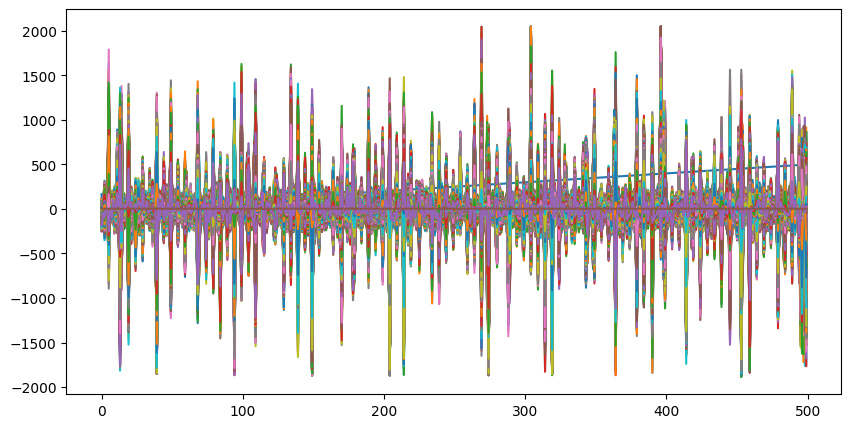

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(df_data)
plt.show()

In [6]:
df_data.head(10)

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X4086,X4087,X4088,X4089,X4090,X4091,X4092,X4093,X4094,y
0,0,-56,-50,-64,-91,-135,-140,-134,-114,-115,...,-37,-43,-63,-82,-114,-138,-159,-172,-180,5
1,1,14,25,31,36,33,33,27,27,21,...,-45,-32,-6,-7,-2,-20,-34,-40,-40,5
2,2,-159,-176,-174,-145,-101,-45,0,29,15,...,-40,-25,14,56,73,48,-12,-62,-100,4
3,3,34,31,29,19,16,12,3,-1,-5,...,-34,-33,-29,-22,-18,-14,-10,-9,0,3
4,4,44,50,46,43,43,46,45,40,36,...,4,5,6,6,2,1,0,-1,-4,2
5,5,142,262,382,451,452,435,544,562,462,...,164,-2,-118,-223,-304,-350,-339,-299,-253,1
6,6,-64,-72,-52,-24,4,21,18,-16,-53,...,-90,-85,-66,-42,-26,-10,-1,-12,-16,5
7,7,-55,-48,-48,-38,-23,0,11,22,21,...,51,61,64,42,-1,-53,-79,-93,-95,4
8,8,18,14,13,9,-6,-20,-31,-27,-10,...,-17,-3,9,25,49,63,82,96,102,4
9,9,50,48,45,41,47,51,53,40,37,...,-16,-30,-47,-63,-63,-50,-39,-25,-19,3


### First 5 classes

In [7]:
print(egg_list[1])
print(df_data.iloc[1])

[  1  14  25 ... -40 -40   5]
Unnamed: 0     1
X1            14
X2            25
X3            31
X4            36
              ..
X4091        -20
X4092        -34
X4093        -40
X4094        -40
y              5
Name: 1, Length: 4096, dtype: int64


### Plot the first Class

Text(0, 0.5, 'Amplitude')

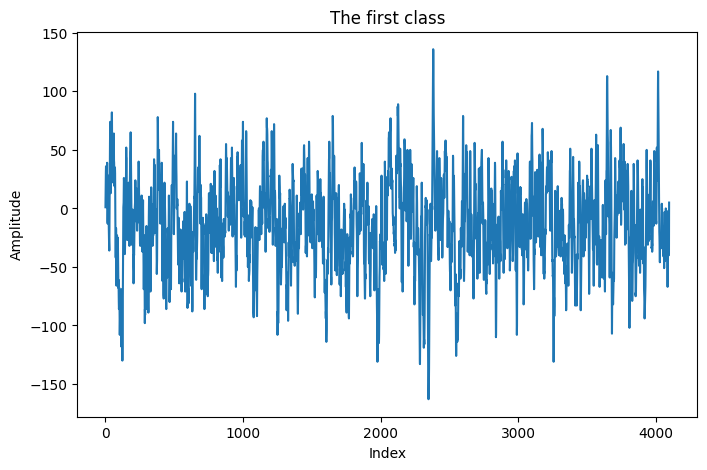

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(egg_list[1])
plt.title("The first class")
plt.xlabel("Index")
plt.ylabel("Amplitude")


### Find all the subject of level 2, and 3 in the dataset  
### get insidght only the passient level 2 vs 3
### Readeing atutomatically classified without level to inform the parrent which level the
### Find the training and testing dataset
### Find the outlyier
### Characterized the dataset
### Training the model
### ===> 26th of the March both random forrest &

In [9]:
from enum import unique
unique_y = df_data['y'].unique()
print(unique_y)

[5 4 3 2 1]


In [10]:
# Find all the subject of level 2, 3 in the dataset
y_1 = []
y_2 = []
y_3 = []
y_4 = []
y_5 = []
for i in range(len(egg_list)):
  if egg_list[i][-1] == 1:
    y_1.append(egg_list[i])
  elif egg_list[i][-1] == 2:
    y_2.append(egg_list[i])
  elif egg_list[i][-1] == 3:
    y_3.append(egg_list[i])

  elif egg_list[i][-1] == 4:
    y_4.append(egg_list[i])
  elif egg_list[i][-1] == 5:
    y_5.append(egg_list[i])


In [11]:
# Separate the dataset into training set (80%) and test set(20%) and eliminate the unnamed atributes which is the first one
y_1_np = np.array(y_1)
y_2_np = np.array(y_2)
y_3_np = np.array(y_3)
y_4_np = np.array(y_4)
y_5_np = np.array(y_5)

# remove first column
y_1_np = y_1_np[:, 1:]
y_2_np= y_2_np[:, 1:]
y_3_np = y_3_np[:, 1:]
y_4_np = y_4_np[:, 1:]
y_5_np = y_5_np[:, 1:]

train_y1, test_y1 = train_test_split(y_1_np, test_size=0.2, random_state=42)
train_y2, test_y2 = train_test_split(y_2_np, test_size=0.2, random_state=42)
train_y3, test_y3 = train_test_split(y_3_np, test_size=0.2, random_state=42)
train_y4, test_y4 = train_test_split(y_4_np, test_size=0.2, random_state=42)
train_y5, test_y5 = train_test_split(y_5_np, test_size=0.2, random_state=42)


In [12]:
# The mean value of the training dataset for all classes
y_1_mean = np.mean(train_y1, axis=0)
y_2_mean = np.mean(train_y2, axis=0)
y_3_mean = np.mean(train_y3, axis=0)
y_4_mean = np.mean(train_y4, axis=0)
y_5_mean = np.mean(train_y5, axis=0)
print(y_2_mean[10])

14.575


# Normalization using z-transformation

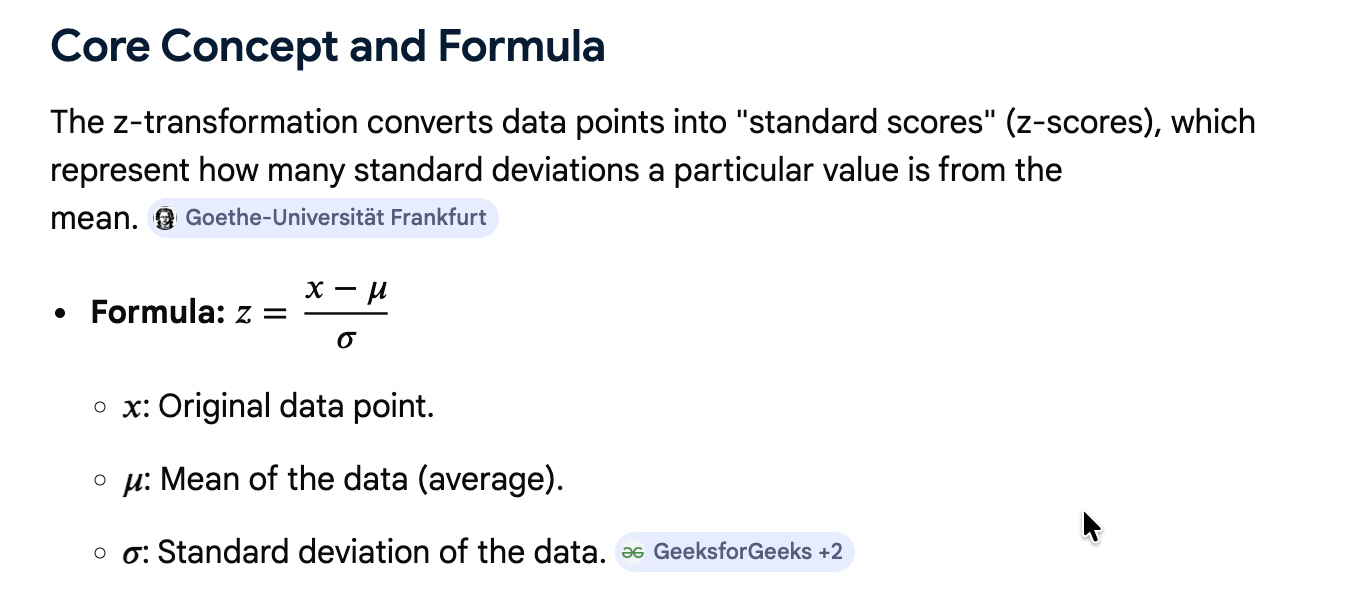

In [13]:
# Normalize with z-transform
def z_tf(x, mean, sigma):
  return ((x-mean)/sigma)



## Task 2

1. **Normalize training & testing signals to the range [0, 1] and plot them.**

2. **Compute the mean and standard deviation of the normalized data.**

3. **Plot the mean of the normalized dataset.**

4. **Identify potential outlier signals**, defined as signals that lie outside the mean ± standard deviation, and plot them

5. **Compute the distance of each signal from the mean in terms of standard deviation.**

6. **Classify a signal as an outlier if its distance is greater than a chosen threshold.** The threshold can be set to 1 or any other value depending on the analysis.


### 1. Normalize training & testing signals of class 2 & 3 and plot them.

In [14]:
# 1. normalize the traingin & testing class 1
y1_training_norm = z_tf(train_y1, np.mean(train_y1), np.std(train_y1))
y1_testing_norm = z_tf(test_y1, np.mean(test_y1), np.std(test_y1))
# 2. normalize the traingin & testing class 2
y2_training_norm = z_tf(train_y2, np.mean(train_y2), np.std(train_y2))
y2_testing_norm = z_tf(test_y2, np.mean(test_y2), np.std(test_y2))
# 3. normalize the traingin & testing class 3
y3_training_norm = z_tf(train_y3, np.mean(train_y3), np.std(train_y3))
y3_testing_norm = z_tf(test_y3, np.mean(test_y3), np.std(test_y3))
# 4. normalize the traingin & testing class 4
y4_training_norm = z_tf(train_y4, np.mean(train_y4), np.std(train_y4))
y4_testing_norm = z_tf(test_y4, np.mean(test_y4), np.std(test_y4))
# 5. normalize the traingin & testing class 5
y5_training_norm = z_tf(train_y5, np.mean(train_y5), np.std(train_y5))
y5_testing_norm = z_tf(test_y5, np.mean(test_y5), np.std(test_y5))


**Plot the normalized dataset**

<Figure size 1800x1000 with 0 Axes>

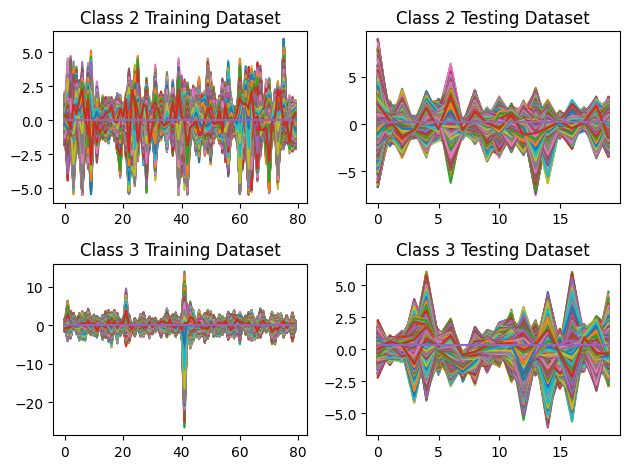

In [15]:
# 1. Plot
plt.figure(figsize=(18, 10))
fig, axes = plt.subplots(nrows=2, ncols=2)
axes = axes.flatten()
axes[0].plot(y1_training_norm , label="Class 2 Training Dataset")
axes[0].set_title("Class 2 Training Dataset")
axes[1].plot(y2_testing_norm, label="Class 2 Testing Dataset")
axes[1].set_title("Class 2 Testing Dataset")
axes[2].plot(y3_training_norm  , label="Class 3 Training Dataset")
axes[2].set_title("Class 3 Training Dataset")
axes[3].plot(y3_testing_norm , label="Class 3 Testing Dataset")
axes[3].set_title("Class 3 Testing Dataset")
fig.tight_layout()

### 2. Compute the mean and standard deviation of the normalized data.

In [16]:
# Mean of the training & testing dataset
y2_training_mean = np.mean(y2_training_norm, axis=0)
y3_training_mean = np.mean(y3_training_norm, axis=0)
y2_testing_mean = np.mean(y2_testing_norm, axis=0)
y3_testing_mean = np.mean(y3_testing_norm, axis=0)
# Standard deviation of the training & testing dataset
y2_training_std = np.std(y2_training_norm, axis=0)
y3_training_std = np.std(y3_training_norm, axis=0)
y2_testing_std = np.std(y2_testing_norm, axis=0)
y3_testing_std = np.std(y3_testing_norm, axis=0)

### 3. Plot the mean & standard deviation of the normalized dataset.

y2_training_mean: [0.064 0.062 0.08  ... 0.034 0.031 0.071] y2_training_std: [0.641 0.661 0.681 ... 0.776 0.78  0.   ]
y3_training_mean: [-0.068 -0.053 -0.079 ...  0.076  0.094  0.143] y3_training_std: [7.52664183e-01 7.76622735e-01 7.98906760e-01 ... 8.78770438e-01
 8.67993738e-01 1.94289029e-16]
y2_testing_mean: [0.364 0.352 0.336 ... 0.156 0.198 0.207] y2_testing_std: [0.79  0.822 0.863 ... 1.228 1.231 0.   ]
y3_testing_mean: [-0.216 -0.305 -0.389 ...  0.123  0.114  0.358] y3_testing_std: [9.10076095e-01 9.12683239e-01 9.52373683e-01 ... 7.48525008e-01
 7.89740593e-01 1.11022302e-16]


<Figure size 1800x1000 with 0 Axes>

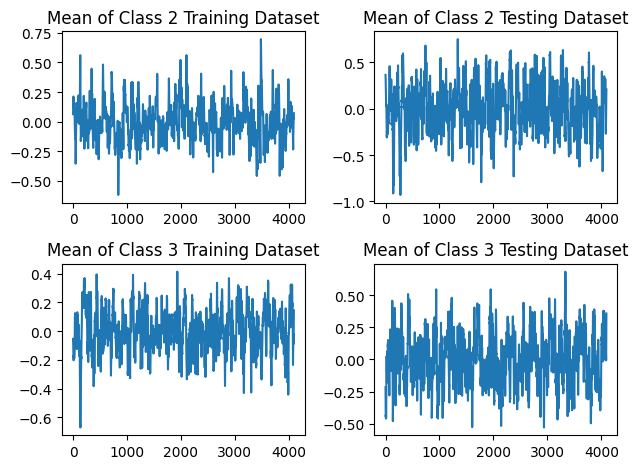

In [17]:

print(f"y2_training_mean: {np.round(y2_training_mean,3)} y2_training_std: {np.round(y2_training_std, 3)}")
print(f"y3_training_mean: {np.round(y3_training_mean,3)} y3_training_std: {y3_training_std}")
print(f"y2_testing_mean: {np.round(y2_testing_mean, 3)} y2_testing_std: {np.round(y2_testing_std, 3)}")
print(f"y3_testing_mean: {np.round(y3_testing_mean, 3)} y3_testing_std: {y3_testing_std}")


plt.figure(figsize=(18, 10))
fig, axes = plt.subplots(nrows=2, ncols=2)
axes = axes.flatten()
axes[0].plot(y2_training_mean , label="Mean of Class 2 Training Data")
axes[0].set_title("Mean of Class 2 Training Dataset")
axes[1].plot(y2_testing_mean, label="Mean of Class 2 Testing Dataset")
axes[1].set_title("Mean of Class 2 Testing Dataset")
axes[2].plot(y3_training_mean , label="Mean of Class 3 Training Data")
axes[2].set_title("Mean of Class 3 Training Dataset")
axes[3].plot(y3_testing_mean, label="Mean of Class 3 Testing Dataset")
axes[3].set_title("Mean of Class 3 Testing Dataset")
fig.tight_layout()


### 4. **Identify potential outlier signals**, defined as signals that lie outside the mean ± standard deviation, and plot them
https://kmr-gautam2893.medium.com/how-to-identify-the-outliers-in-your-data-ee9c28b42fc3

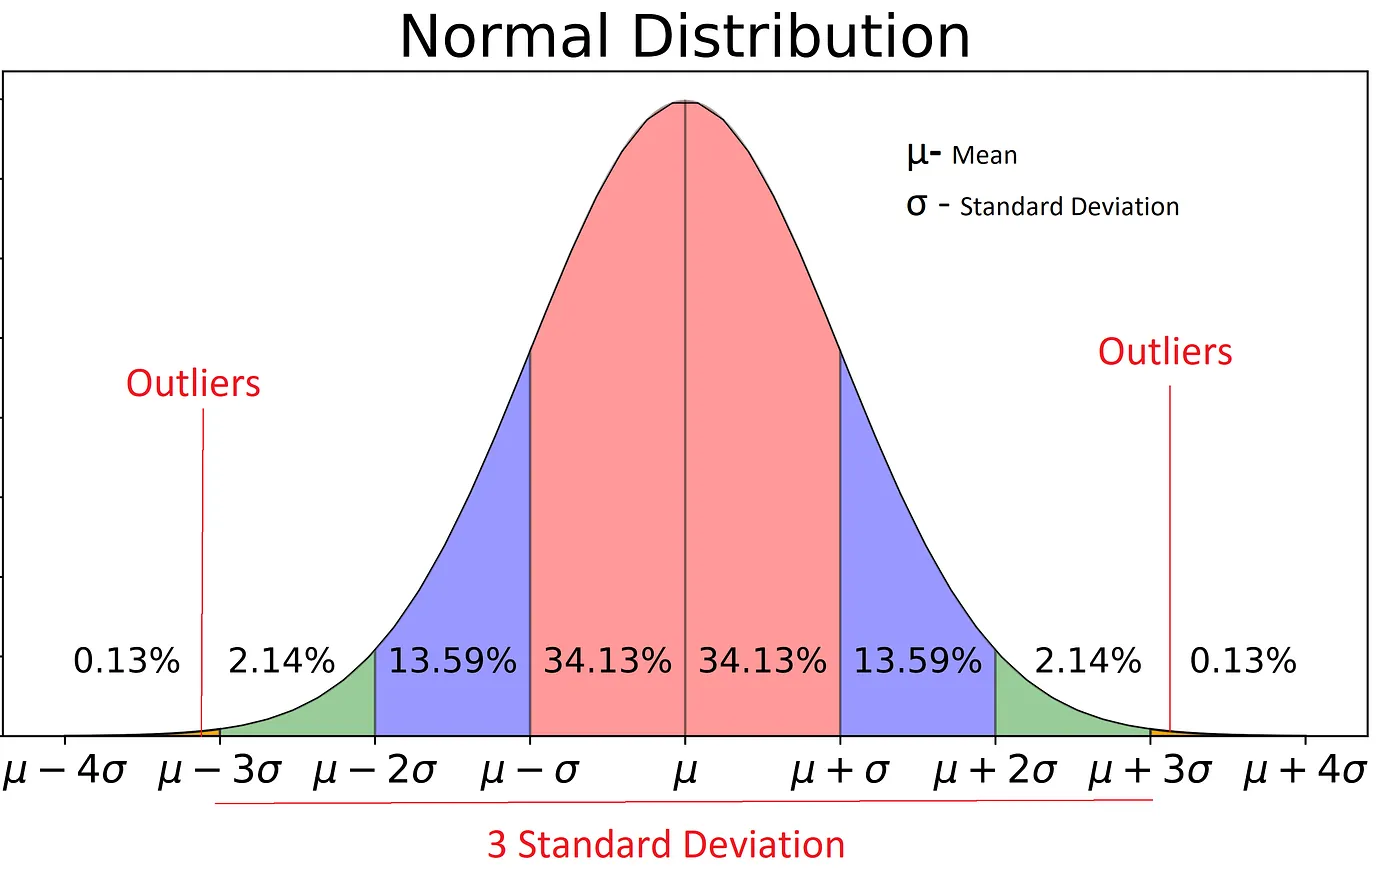

In [18]:
threshold = 3

# Identify rows containing outliers for training data of class 2
outlier_mask_y2_train = (y2_training_norm < -threshold) | (y2_training_norm > threshold)
outlier_rows_y2_train = np.any(outlier_mask_y2_train, axis=1)
y2_training_outliers = y2_training_norm[outlier_rows_y2_train]

y2_train_without_norm_outlier = y2_training_norm[~outlier_rows_y2_train]

# Identify rows containing outliers for testing data of class 2
outlier_mask_y2_test = (y2_testing_norm < -threshold) | (y2_testing_norm > threshold)
outlier_rows_y2_test = np.any(outlier_mask_y2_test, axis=1)
y2_testing_outliers = y2_testing_norm[outlier_rows_y2_test]
y2_test_without_norm_outlier = y2_testing_norm[~outlier_rows_y2_test]

# Identify rows containing outliers for training data of class 3
outlier_mask_y3_train = (y3_training_norm < -threshold) | (y3_training_norm > threshold)
outlier_rows_y3_train = np.any(outlier_mask_y3_train, axis=1)
y3_training_outliers = y3_training_norm[outlier_rows_y3_train]
y3_train_without_norm_outlier = y3_training_norm[~outlier_rows_y3_train]

# Identify rows containing outliers for testing data of class 3
outlier_mask_y3_test = (y3_testing_norm < -threshold) | (y3_testing_norm > threshold)
outlier_rows_y3_test = np.any(outlier_mask_y3_test, axis=1)
y3_testing_outliers = y3_testing_norm[outlier_rows_y3_test]
y3_test_without_norm_outlier = y3_testing_norm[~outlier_rows_y3_test]



<Figure size 1500x800 with 0 Axes>

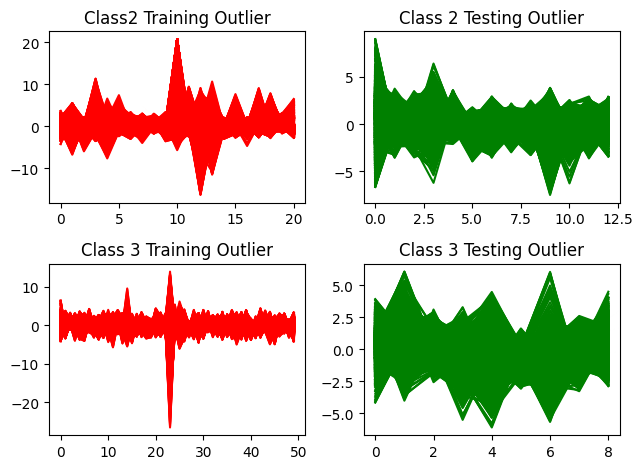

In [19]:
# 1. Plot
plt.figure(figsize=(15, 8))
fig, axes = plt.subplots(nrows=2, ncols=2)
axes = axes.flatten()
axes[0].plot(y2_training_outliers, 'r-', label="Class 2 Training Outlier")
axes[0].set_title("Class2 Training Outlier")
axes[1].plot(y2_testing_outliers, 'g-', label="Class 2 Testing Outlier")
axes[1].set_title("Class 2 Testing Outlier")
axes[2].plot(y3_training_outliers ,'r-' , label="Class 3 Training Outlier")
axes[2].set_title("Class 3 Training Outlier")
axes[3].plot(y3_testing_outliers, 'g-' , label="Class 3 Testing Outlier")
axes[3].set_title("Class 3 Testing Outlier")
fig.tight_layout()

## Train a linear kernel SVM classifier using 80% of the dataset containing the outlier and evaluate its performance. Then remove the outlier, repeat the 80/20 training–testing process, and compare the results.

Linear Models

In [20]:
# find label for class 2 & 3
train_class_2 = np.zeros(len(y2_training_norm))
train_class_3 = np.ones(len(y3_training_norm))

test_class_2 = np.zeros(len(y2_testing_norm))
test_class_3 = np.ones(len(y3_testing_norm))

In [21]:
# Prepare the trianing and testing dataset
final_train = np.vstack((y2_training_norm, y3_training_norm))
final_test = np.vstack((y2_testing_norm, y3_testing_norm))
final_train.shape, final_test.shape

((160, 4095), (40, 4095))

In [22]:
# Prepare the training and testing dataset
final_train = np.vstack((y2_training_norm, y3_training_norm))
final_test = np.vstack((y2_testing_norm, y3_testing_norm))
final_train.shape, final_test.shape


((160, 4095), (40, 4095))

In [23]:
final_y_train = np.hstack((train_class_2, train_class_3))

final_y_test = np.hstack((test_class_2, test_class_3))

Best params: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV ROC-AUC: 0.91328125


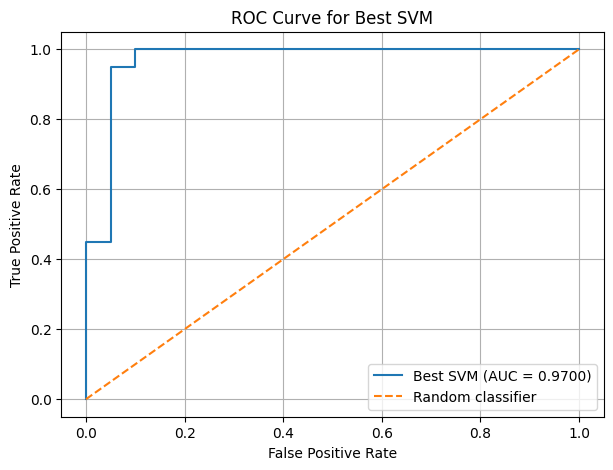

In [24]:
# pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

# hyperparameter grid
param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.01, 0.1, 1, 10, 100],
        "svm__gamma": ["scale", "auto", 0.1, 0.01, 0.001]
    }
]

# cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(final_train, final_y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_model = grid.best_estimator_

# ROC on test set
y_score = best_model.predict_proba(final_test)[:, 1]
fpr, tpr, _ = roc_curve(final_y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Best SVM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Best SVM")
plt.legend()
plt.grid(True)
plt.show()

Training The Linear Model

## Train a linear kernel SVM classifier using 80% of the dataset **without** the outlier and evaluate its performance, and compare the results.

 Now We have to separate the dataset from outliers
**Remove the outlier**


In [25]:
final_train_without_outlier = np.vstack((y2_train_without_norm_outlier, y3_train_without_norm_outlier))
final_test_without_outlier = np.vstack((y2_test_without_norm_outlier, y3_test_without_norm_outlier))
final_train_without_outlier.shape, final_test_without_outlier.shape

((89, 4095), (18, 4095))

In [26]:
# Create labels for the filtered training data
final_y_train_without_outlier = np.concatenate((
    train_class_2[~outlier_rows_y2_train],
    train_class_3[~outlier_rows_y3_train]
))
final_y_test_without_outlier = np.concatenate((
    test_class_2[~outlier_rows_y2_test],
    test_class_3[~outlier_rows_y3_test]
))


In [27]:
# model
rf = RandomForestClassifier(random_state=42)

# hyperparameter grid
param_grid = {
    "n_estimators": [200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

# cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# grid search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",   # or "f1", "roc_auc", etc.
    n_jobs=-1
)

# fit on training data
grid.fit(final_train, final_y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_rf = grid.best_estimator_


Best parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 1.0


In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = best_rf.predict(final_test)

print("Test accuracy:", accuracy_score(final_y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(final_y_test, y_pred))

Test accuracy: 0.5
Confusion matrix:
 [[ 0 20]
 [ 0 20]]
